# 05 · Phase 7 — Candidate representations and configuration feature groups

**Action space** (discrete, multi-categorical; 5 × 3 × 5 × 4 × 7 = **2,100 configurations**):

| Component | Options | What it changes |
|---|---|---|
| wavelet family | db4, db6, db8, sym4, coif3 | mother wavelet of the wavelet-packet (W) branch |
| decomposition level | 3, 4, 5 | 8 / 16 / 32 frequency-ordered sub-bands (time vs frequency resolution) |
| frequency band | 20–100, 100–200, 200–400, 400–800, 20–800 Hz | rows of the STFT and wavelet-packet images that are used |
| temporal window | 0.5, 1, 2, 4 s | analysis window: feature pooling (proxy) / network input length (deep) |
| fusion | T, S, W, TS, TW, SW, TSW | which branches are fused (temporal, STFT, wavelet) |

*Change vs the draft plan:* the 0.25 s window was replaced by 4 s. At pediatric heart rates
(median ≈ 100–130 bpm in CirCor) 0.25 s is shorter than one systole + diastole and cannot hold
a murmur's context, while multi-cycle windows (≈ 4 s) are what the strongest CirCor systems use.

The wavelet branch uses a **wavelet-packet** decomposition in frequency order, which turns any
discrete wavelet (db/sym/coif — for which a CWT is not defined) into a genuine time–frequency image.

For the RL reward oracle every recording gets three feature groups per configuration
(computed for the clean signal and for a **10 dB pink-noise** copy used by the robustness reward):
* **W** (wavelet, level, band, window): per sub-band log-energy mean/std, within-window floor-to-peak ratio, sub-band entropy
* **S** (band, window): STFT band power, centroid, bandwidth, flatness, entropy, floor-to-peak, 8-bin spectral profile
* **T** (window): envelope floor-to-peak, RMS, ZCR, kurtosis, cycle regularity (autocorrelation)

In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")
%run ../common/01_signal_lib.ipynb
%run ../common/02_rl_lib.ipynb
import zlib
import joblib
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

df = pd.read_csv(P["metadata"] / "records_qc.csv")
df = df[df.qc_keep].reset_index(drop=True)
sig = np.load(P["segments"] / "signals.npz")
fs = CFG["preprocessing"]["fs"]
space = ConfigSpace(CFG)
print(space.n, "configurations; baseline =", space.label(space.baseline))

CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


loaded 01_signal_lib


loaded 02_rl_lib


2100 configurations; baseline = db6-L5-20-800Hz-2.0s-TSW


## Candidate time–frequency images for one murmur recording

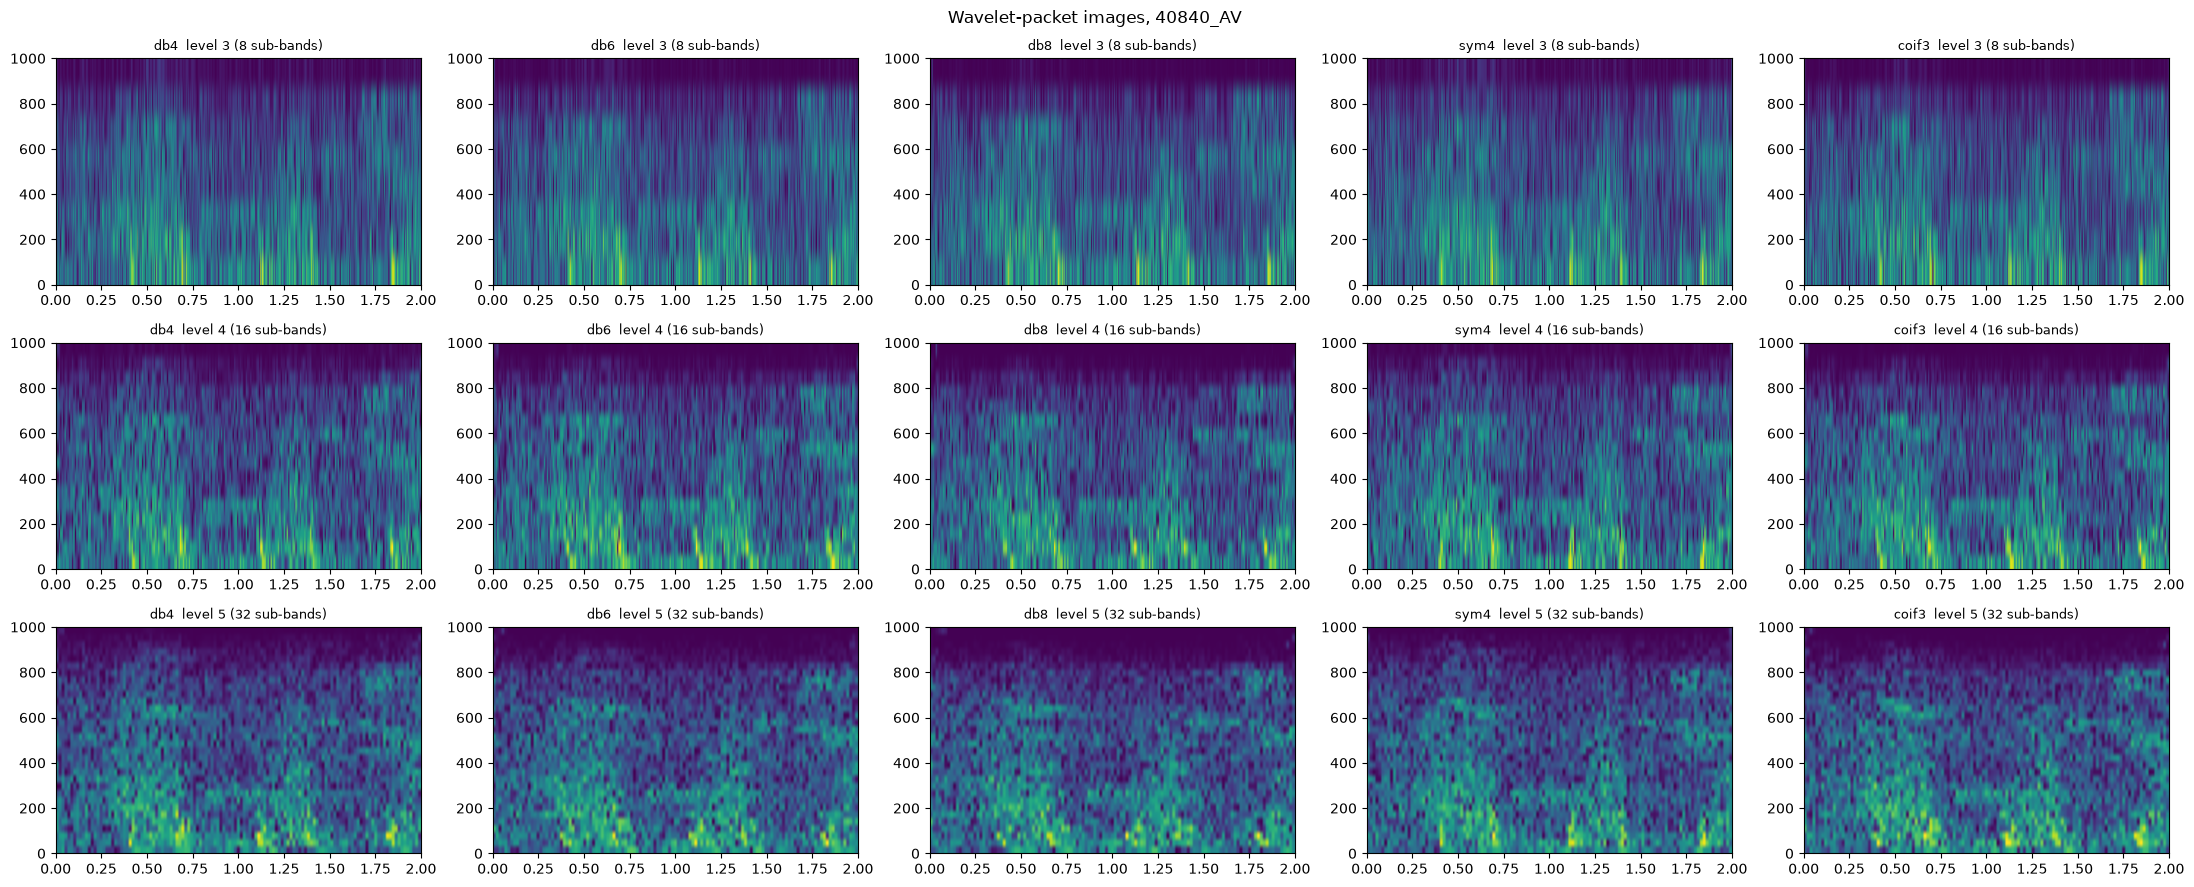

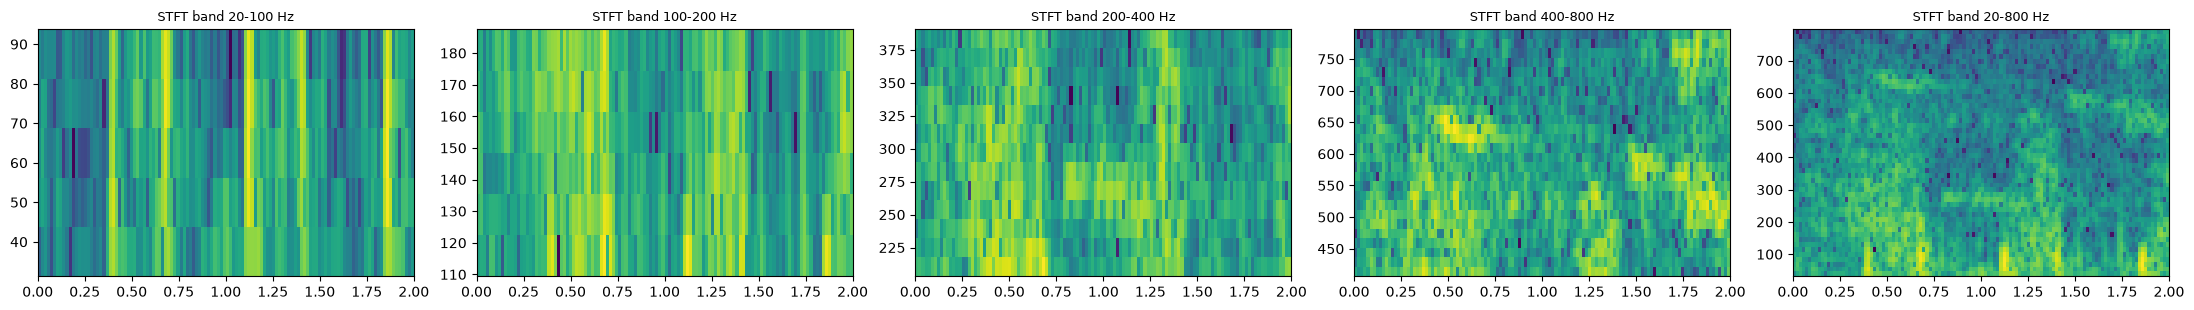

In [2]:
rid = df[(df.murmur_label == "Present") & (df.sys_grading == "III/VI")].record_id.iloc[0]
x = sig[rid].astype(np.float32)[: 2 * fs]
fig, ax = plt.subplots(3, 5, figsize=(22, 9))
for j, wv in enumerate(CFG["actions"]["wavelet"]):
    for i, L in enumerate(CFG["actions"]["level"]):
        M = wavelet_packet_matrix(x[: (len(x) // 2 ** L) * 2 ** L], wv, L)
        ax[i, j].imshow(log_compress(M), origin="lower", aspect="auto", extent=[0, 2, 0, 1000])
        ax[i, j].set_title(f"{wv}  level {L} ({2 ** L} sub-bands)", fontsize=9)
plt.suptitle(f"Wavelet-packet images, {rid}"); plt.tight_layout(); savefig(fig, "05_wavelet_packet_grid"); plt.show()

fig, ax = plt.subplots(1, 5, figsize=(22, 3.2))
fq, Pw = stft_power(x, fs, 128, 32)
for a, (lo, hi) in zip(ax, CFG["actions"]["band"]):
    m = (fq >= lo) & (fq <= hi)
    a.imshow(np.log(Pw[m] + 1e-6), origin="lower", aspect="auto", extent=[0, 2, fq[m][0], fq[m][-1]])
    a.set_title(f"STFT band {lo}-{hi} Hz", fontsize=9)
plt.tight_layout(); savefig(fig, "05_stft_bands"); plt.show()

## Wavelet shapes (scaling / wavelet functions)

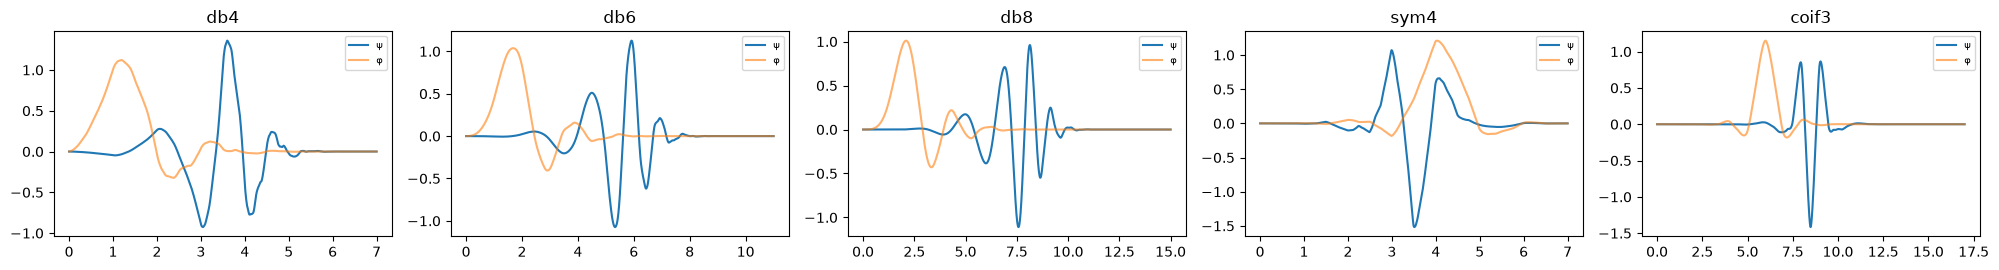

In [3]:
fig, ax = plt.subplots(1, 5, figsize=(20, 2.8))
for a, wv in zip(ax, CFG["actions"]["wavelet"]):
    phi, psi, xx = pywt.Wavelet(wv).wavefun(level=8)
    a.plot(xx, psi, label="ψ"); a.plot(xx, phi, alpha=0.6, label="φ"); a.set_title(wv); a.legend(fontsize=7)
plt.tight_layout(); savefig(fig, "05_wavelet_shapes"); plt.show()

## Feature extraction for all configurations (clean + 10 dB pink noise)

In [4]:
snr, kind = CFG["reward"]["robustness_snr_db"], CFG["reward"]["robustness_noise"]


def work(rid, x):
    x = x.astype(np.float32)
    rng = np.random.default_rng(zlib.crc32(rid.encode()))
    xn = add_noise(x, snr, rng, kind, fs)
    return recording_features(x, CFG), recording_features(xn, CFG)


t0 = time.time()
res = Parallel(n_jobs=-2, batch_size=4)(delayed(work)(r, sig[r]) for r in df.record_id)
print(f"feature extraction for {len(df)} recordings: {time.time() - t0:.0f}s")
keys = list(res[0][0].keys())
feats = {"record_id": df.record_id.tolist(),
         "clean": {k: np.stack([r[0][k] for r in res]) for k in keys},
         "noisy": {k: np.stack([r[1][k] for r in res]) for k in keys}}
joblib.dump(feats, P["processed"] / "config_features.joblib", compress=3)
dims = pd.Series({str(k): v.shape[1] for k, v in feats["clean"].items()})
print(len(keys), "feature groups; dims: T", dims[[s for s in dims.index if s.startswith("('T'")]].iloc[0],
      "| S", dims[[s for s in dims.index if s.startswith("('S'")]].iloc[0],
      "| W range", dims[[s for s in dims.index if s.startswith("('W'")]].min(), "-", dims[[s for s in dims.index if s.startswith("('W'")]].max())

feature extraction for 3163 recordings: 3217s


324 feature groups; dims: T 10 | S 20 | W range 8 - 83
